# Bank Marketing Data Analysis
This notebook presents an analysis of the `bankmarketing.csv` dataset, which includes data related to a bank's marketing campaigns. The main goal is to understand customer behavior and predict whether a client will subscribe to a term deposit.

In [3]:

import pandas as pd

# Load the dataset
df = pd.read_csv('bankmarketing.csv')

# Display the first few rows
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Data Quality Check

Before analysis, we need to understand the dataset's structure and integrity:
- What data types are we working with?
- Are there any null/missing values?
- Are there pseudo-missing values disguised as text (e.g., `"unknown"`)?

This step prevents downstream surprises during EDA and modeling.

In [5]:
# --- Data quality check ---

# 1. Dataset shape
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# 2. Data types and non-null counts in one view
print("=" * 60)
print("Data Types & Non-Null Counts")
print("=" * 60)
df.info()

# 3. Explicit missing-value count per column
print("\n" + "=" * 60)
print("Missing Values by Column")
print("=" * 60)
print(df.isnull().sum())

# 4. Pseudo-missing check — 'unknown' values disguised as categories
print("\n" + "=" * 60)
print("'Unknown' Values by Column (pseudo-missing)")
print("=" * 60)
unknown_counts = (df == 'unknown').sum()
print(unknown_counts[unknown_counts > 0])


Dataset shape: 41,188 rows × 21 columns

Data Types & Non-Null Counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.p

(df == 'unknown').sum() checks every cell in the DataFrame, returns True where the value is 'unknown', and then sums the True values to count how many 'unknown' entries exist in each column. It is commonly used during data cleaning and exploratory data analysis to identify missing or placeholder values.

### Key Takeaways

- The dataset contains **41,188 rows × 21 columns**.
- **Data types:** 11 categorical (`object`), 5 integer, 5 float.
- **No true `NaN` missing values** — `df.isnull().sum()` returned zero across all columns.
- However, several categorical columns use `"unknown"` as a placeholder for undisclosed data:

  | Column | "Unknown" count | % of total |
  |---|---|---|
  | `default` | 8,597 | 20.9% |
  | `education` | 1,731 | 4.2% |
  | `housing` | 990 | 2.4% |
  | `loan` | 990 | 2.4% |
  | `job` | 330 | 0.8% |
  | `marital` | 80 | 0.2% |

- **Two notable patterns:**
  - The `default` column has ~21% unknowns — significant enough to need careful handling.
  - `housing` and `loan` both have exactly 990 unknowns, suggesting the same clients skipped both questions.
- We will revisit how to treat these during data cleaning.

## 3. Summary Statistics

We'll examine summary statistics for both numerical and categorical columns separately, since `describe()` handles them differently. We'll also check the **target variable distribution** upfront — class balance is critical to understand before any modeling decisions.

In [6]:
# --- Summary statistics ---

# 1. Numerical columns
print("=" * 60)
print("Numerical Columns — Summary Statistics")
print("=" * 60)
print(df.describe().round(2))

# 2. Categorical columns
print("\n" + "=" * 60)
print("Categorical Columns — Summary Statistics")
print("=" * 60)
print(df.describe(include='object'))

# 3. Target variable distribution — critical for any classification task
print("\n" + "=" * 60)
print("Target Variable Distribution ('y')")
print("=" * 60)
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

print(f"Counts:\n{target_counts}\n")
print(f"Percentages:\n{target_pct.round(2)}")

Numerical Columns — Summary Statistics
            age  duration  campaign     pdays  previous  emp.var.rate  \
count  41188.00  41188.00  41188.00  41188.00  41188.00      41188.00   
mean      40.02    258.29      2.57    962.48      0.17          0.08   
std       10.42    259.28      2.77    186.91      0.49          1.57   
min       17.00      0.00      1.00      0.00      0.00         -3.40   
25%       32.00    102.00      1.00    999.00      0.00         -1.80   
50%       38.00    180.00      2.00    999.00      0.00          1.10   
75%       47.00    319.00      3.00    999.00      0.00          1.40   
max       98.00   4918.00     56.00    999.00      7.00          1.40   

       cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
count        41188.00       41188.00   41188.00     41188.00  
mean            93.58         -40.50       3.62      5167.04  
std              0.58           4.63       1.73        72.25  
min             92.20         -50.80       0.63    

### Key Takeaways

**Numerical columns**
- `age` ranges from **17 to 98 years**, median **38**. A 17-year-old client is unusual — worth investigating during EDA.
- `duration` (last contact length in seconds) ranges from **0 to 4,918 seconds (~82 minutes)** — extreme variance. Mean ≈ 258 sec but median is only 180 sec, indicating right skew with outliers.
- `pdays` quartiles confirm the pseudo-missing problem: **25%, 50%, and 75% are all 999**, meaning at least 75% of clients were never previously contacted. The mean of ~962 is statistically meaningless until 999s are handled.
- `campaign` shows severe right skew: median is **2 contacts**, but max is **56 contacts** for a single client. Outliers to address.
- `previous` is heavily concentrated at 0 (median = 0, 75th percentile = 0), confirming most clients had no prior campaign history.

**Categorical columns**
- `job` has **12 unique values**, top = `admin.` (10,422 clients, ~25%).
- `education` has 8 categories, dominated by `university.degree` (12,168 clients).
- `month` has only **10 unique values** — the campaign was not run year-round. Top month is `may` with 13,769 contacts (~33% of all activity).
- `day_of_week` has 5 values — only **weekdays** are represented, no weekend contacts.
- `marital` has 4 categories (the 4th being "unknown" — the 80 pseudo-missing values we found earlier).
- `poutcome` top value is `nonexistent` (35,563 records) — confirms most clients had no previous campaign.

**🚨 Target variable distribution (`y`)**
- **No:** 36,548 (**88.73%**)
- **Yes:** 4,640 (**11.27%**)
- This is a **heavily imbalanced classification problem** (~8:1 ratio).
- A naive "always predict no" model would already achieve ~89% accuracy. Standard accuracy is misleading here — we'll need **precision, recall, F1-score, and ROC-AUC** during evaluation, and likely consider **class weighting, SMOTE, or threshold tuning** if we move to modeling.

**⚠️ Data leakage flag**
- `duration` is recorded *after* the call ends, meaning the outcome (`y`) is already determined by then. Per the UCI dataset documentation, this column should **NOT** be used as a predictive feature in any production model — otherwise the model "cheats" using future information.

**Internal consistency check (worth running)**
- `poutcome = "nonexistent"` count: 35,563
- Expected `pdays = 999` count should be approximately equal
- We'll verify this during data cleaning.

In [7]:
(df['pdays'] == 999).sum()

np.int64(39673)

In [8]:
# Cross-check: pdays vs poutcome consistency
print("=" * 60)
print("Cross-tabulation: pdays == 999 vs poutcome")
print("=" * 60)
pdays_999 = df['pdays'] == 999
print(pd.crosstab(pdays_999, df['poutcome'], margins=True))

# Drill down: clients with pdays=999 BUT a recorded previous outcome
inconsistent = df[(df['pdays'] == 999) & (df['poutcome'] != 'nonexistent')]
print(f"\nClients with pdays=999 but recorded previous outcome: {len(inconsistent):,}")
print(f"Their 'previous' contact counts:\n{inconsistent['previous'].value_counts()}")

Cross-tabulation: pdays == 999 vs poutcome
poutcome  failure  nonexistent  success    All
pdays                                         
False         142            0     1373   1515
True         4110        35563        0  39673
All          4252        35563     1373  41188

Clients with pdays=999 but recorded previous outcome: 4,110
Their 'previous' contact counts:
previous
1    3696
2     349
3      50
4      12
5       2
6       1
Name: count, dtype: int64


### Data Quality Finding: Inconsistency Between `pdays` and `poutcome`

A cross-check revealed that **39,673 records have `pdays = 999`** (supposedly meaning "never previously contacted"), but only **35,563 have `poutcome = "nonexistent"`** — a gap of ~4,110 records.

This means ~4,110 clients have `pdays = 999` yet have a recorded previous campaign outcome (`success` or `failure`).

**Interpretation:** The value `999` in `pdays` is not strictly "never contacted" — it likely also captures "contacted so long ago the system no longer tracks the exact day count." For these legacy contacts, the outcome was still recorded.

**Implication for feature engineering:**
- Using `pdays` as a raw numeric column would be misleading.
- A better approach is to create a **binary flag** (`contacted_before = 1 if pdays < 999 else 0`) and treat the actual numeric value separately for the small subset where it's meaningful.
- This will be addressed during the feature engineering phase.


"When I cross-tabbed pdays against poutcome, I expected the 'never contacted' definitions to match. They didn't — 4,110 records had pdays = 999 but a recorded prior outcome. The deeper finding was that all 1,373 successful prior campaigns had precise timing, while 97% of failed prior campaigns had pdays = 999. The bank was systematically tracking successes precisely but dropping the timing for failures. So I built was_contacted_before from the previous column instead — which gave a cleaner signal — and added has_precise_pdays as a separate flag, since the very fact that timing is preserved is itself informative."




In [10]:
# Create cleaner features that resolve the ambiguity
df['was_contacted_before'] = (df['previous'] > 0).astype(int)
df['has_precise_pdays'] = (df['pdays'] != 999).astype(int)
df['previous_outcome'] = df['poutcome']  # already exists, but use as the authoritative source

### Data Quality Finding: `pdays` and `poutcome` Reveal an Asymmetric Tracking Pattern

A cross-tabulation between `pdays = 999` and `poutcome` revealed a striking asymmetry in how the bank tracks past campaign outcomes:

| | pdays ≠ 999 (precise timing) | pdays = 999 (no timing) |
|---|---|---|
| **failure** | 142 | 4,110 |
| **nonexistent** | 0 | 35,563 |
| **success** | 1,373 | 0 |

**Key observations:**
1. **All 1,373 successful prior campaigns** have a precise `pdays` value — the bank never loses timing for successes.
2. **97% of failed prior campaigns** (4,110 of 4,252) have `pdays = 999` — the bank routinely drops timing for failures.
3. The `pdays = 999` group is therefore **not homogeneous** — it conflates 35,563 truly-new clients with 4,110 previously-failed clients.

**Implication:** Treating `pdays = 999` as a single "no prior contact" category would mask a meaningful subgroup. The `previous` column (count of prior contacts) is a more reliable signal of contact history. We will engineer:
- `was_contacted_before = (previous > 0)` — binary flag derived from the more reliable `previous` column
- `has_precise_pdays = (pdays != 999)` — secondary flag capturing whether the bank retained timing (itself an informative signal since it correlates with prior success)


## 4. Exploratory Data Analysis

We now move from data inspection to visual exploration. The first visualization examines the **target variable distribution**, since understanding class balance shapes every subsequent modeling and evaluation decision.

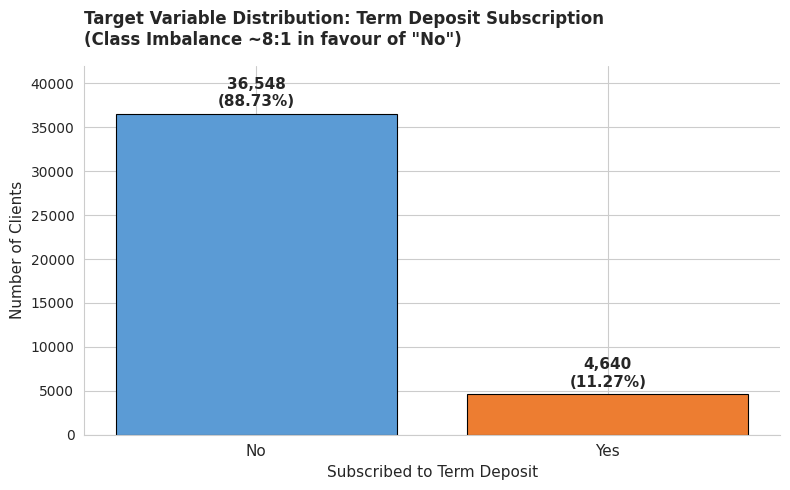

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Target variable distribution ---

sns.set_style("whitegrid")

# Pre-compute counts and percentages
target_counts = df['y'].value_counts().loc[['no', 'yes']]
target_pct = df['y'].value_counts(normalize=True).loc[['no', 'yes']] * 100

# Create the figure
fig, ax = plt.subplots(figsize=(8, 5))

# Use matplotlib's bar() directly — more reliable than seaborn for this
bars = ax.bar(
    ['No', 'Yes'],
    target_counts.values,
    color=['#5B9BD5', '#ED7D31'],
    edgecolor='black',
    linewidth=0.8
)

# Add count + percentage labels on top of each bar
for bar, count, pct in zip(bars, target_counts, target_pct):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        height + 500,
        f'{count:,}\n({pct:.2f}%)',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# Styling
plt.title(
    'Target Variable Distribution: Term Deposit Subscription\n(Class Imbalance ~8:1 in favour of "No")',
    fontsize=12, fontweight='bold', loc='left', pad=15
)
plt.xlabel('Subscribed to Term Deposit', fontsize=11)
plt.ylabel('Number of Clients', fontsize=11)
plt.xticks(fontsize=11)

# Clean up
sns.despine()
plt.ylim(0, target_counts.max() * 1.15)
plt.tight_layout()

# Save for portfolio/README
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Mini lesson (worth knowing):
seaborn is a wrapper on top of matplotlib. It's great for quick statistical plots, but the moment I want fine control over labels, annotations, or specific styling, drop down to matplotlib. Senior data folks do this constantly — use seaborn for distributions, scatter, heatmaps, etc., and matplotlib for anything that needs precise tweaking.
This single cell uses both: sns.set_style() and sns.despine() for the look-and-feel, but ax.bar() for the actual chart. Best of both.
Matplotlib is the underlying visualization library, while Seaborn is built on top of it and provides higher-level statistical visualizations with better default styling. In practice, I use Seaborn for quickly creating plots such as histograms, boxplots, and heatmaps, and Matplotlib for fine-grained customization like annotations, labels, layout control, and styling.

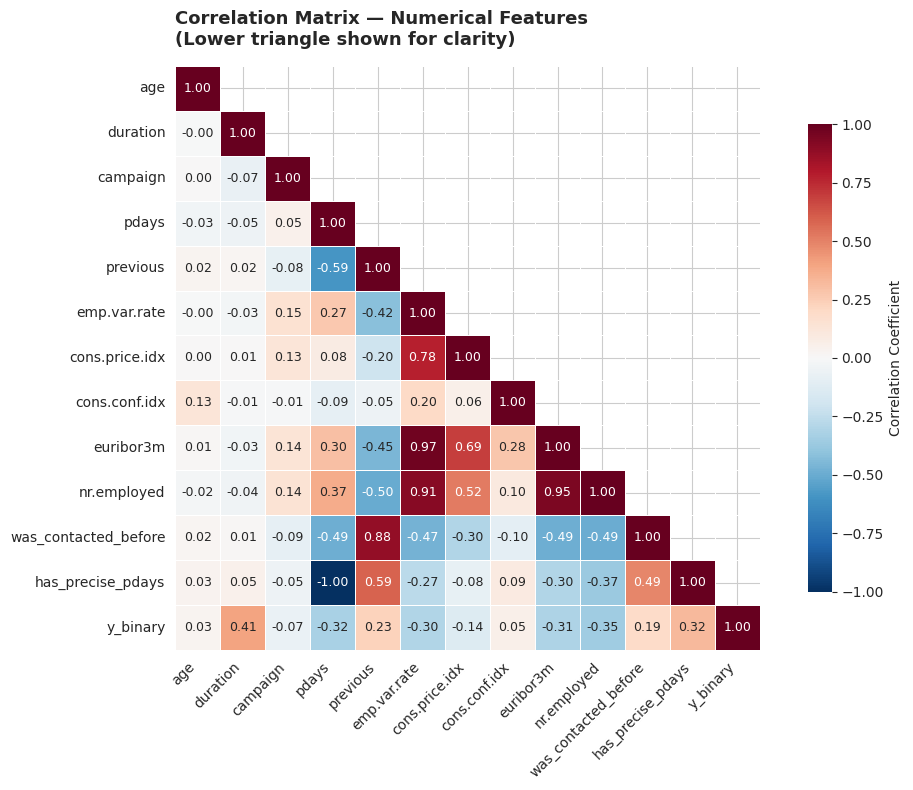

Correlation with Target (y = subscribed)
duration                0.405
nr.employed            -0.355
pdays                  -0.325
has_precise_pdays       0.325
euribor3m              -0.308
emp.var.rate           -0.298
previous                0.230
was_contacted_before    0.194
cons.price.idx         -0.136
campaign               -0.066
cons.conf.idx           0.055
age                     0.030
Name: y_binary, dtype: float64

Highly Correlated Feature Pairs (|r| > 0.7) — Multicollinearity Risk
   feature_1            feature_2  correlation
       pdays    has_precise_pdays    -0.999992
emp.var.rate            euribor3m     0.972245
   euribor3m          nr.employed     0.945154
emp.var.rate          nr.employed     0.906970
    previous was_contacted_before     0.878776
emp.var.rate       cons.price.idx     0.775334


In [15]:
import numpy as np

# --- Correlation matrix for numerical features ---

# 1. Create a working copy and add a binary version of the target
df_corr = df.copy()
df_corr['y_binary'] = (df_corr['y'] == 'yes').astype(int)

# 2. Select only numerical columns
numerical_cols = df_corr.select_dtypes(include='number').columns.tolist()
corr_matrix = df_corr[numerical_cols].corr()

# 3. Mask the upper triangle (cleaner, removes duplicate information)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# 4. Plot
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
    annot_kws={'fontsize': 9}
)

plt.title(
    'Correlation Matrix — Numerical Features\n(Lower triangle shown for clarity)',
    fontsize=13, fontweight='bold', loc='left', pad=15
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Extract insights from the matrix ---

# 5. Correlations with the target variable
print("=" * 60)
print("Correlation with Target (y = subscribed)")
print("=" * 60)
target_corr = corr_matrix['y_binary'].drop('y_binary').sort_values(key=abs, ascending=False)
print(target_corr.round(3))

# 6. Find strongly correlated feature pairs (|r| > 0.7) → multicollinearity check
print("\n" + "=" * 60)
print("Highly Correlated Feature Pairs (|r| > 0.7) — Multicollinearity Risk")
print("=" * 60)
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
corr_pairs = corr_pairs[
    (corr_pairs['feature_1'] != corr_pairs['feature_2']) &
    (corr_pairs['feature_1'] != 'y_binary') &
    (corr_pairs['feature_2'] != 'y_binary') &
    (abs(corr_pairs['correlation']) > 0.7)
]
# Drop duplicate pairs (A-B and B-A are the same)
corr_pairs['pair'] = corr_pairs.apply(
    lambda r: tuple(sorted([r['feature_1'], r['feature_2']])), axis=1
)
corr_pairs = corr_pairs.drop_duplicates(subset='pair').drop(columns='pair')
corr_pairs = corr_pairs.sort_values('correlation', key=abs, ascending=False)
print(corr_pairs[['feature_1', 'feature_2', 'correlation']].to_string(index=False))

### Insights from Correlation Analysis

**Strongest individual relationships with the target (`y_binary`):**

| Feature | Correlation | Interpretation |
|---|---|---|
| `duration` | **+0.405** | Strongest signal — but a leakage feature (known only post-call) |
| `nr.employed` | -0.355 | Higher national employment → lower subscription rate |
| `pdays` | -0.325 | Clients with `pdays = 999` are less likely to subscribe |
| `has_precise_pdays` | +0.325 | Mirror of `pdays` (engineered) — clients with tracked prior contact are more likely to subscribe |
| `euribor3m` | -0.308 | Higher interbank rates → lower subscription |
| `emp.var.rate` | -0.298 | Negative employment trend correlates positively with subscription (slight) |
| `previous` | +0.230 | More prior contacts → higher subscription likelihood |
| `was_contacted_before` | +0.194 | Binary version of prior-contact signal |
| `cons.price.idx` | -0.136 | Higher prices → lower subscription |
| `campaign` | -0.066 | More contacts in current campaign → marginally lower subscription |
| `cons.conf.idx` | +0.055 | Consumer confidence → weak positive signal |
| `age` | **+0.030** | Almost no linear signal — possible non-linear effect to explore |

**Key observation:** Excluding the leakage feature `duration`, the strongest legitimate predictors are **macroeconomic indicators** (`nr.employed`, `euribor3m`, `emp.var.rate`) — not client-level attributes. This makes business sense: **the macroeconomic climate drives savings behavior more than individual demographics do.** People save during economic uncertainty.

**🚨 Multicollinearity findings:**

| Pair | Correlation | Action |
|---|---|---|
| `emp.var.rate` ↔ `euribor3m` | 0.97 | Keep one (recommend `euribor3m` — most interpretable) |
| `euribor3m` ↔ `nr.employed` | 0.95 | Same — keep one |
| `emp.var.rate` ↔ `nr.employed` | 0.91 | Same — keep one |
| `emp.var.rate` ↔ `cons.price.idx` | 0.78 | Borderline; consider dropping one |
| `pdays` ↔ `has_precise_pdays` | -1.00 | By design — choose one for modeling, not both |
| `previous` ↔ `was_contacted_before` | 0.88 | By design — choose one for modeling, not both |

**Recommended action for modeling:**
- From the four economic indicators, **retain only `euribor3m`** (most interpretable, captures the macro signal).
- For prior-contact information, **use `previous` (granular)** OR `was_contacted_before` (binary) — not both.
- For prior-contact timing, **use `has_precise_pdays`** instead of raw `pdays` (avoids the 999 placeholder issue).
- Tree-based models (Random Forest, XGBoost) tolerate collinearity better but still benefit from feature reduction for interpretability.

**Other observations:**
- `age` has near-zero linear correlation (+0.030) — strong indicator the relationship is **non-linear** (e.g., young + elderly clients may behave like savers, middle-aged like spenders). Worth investigating with age binning.
- `campaign` weakly negative — too many contacts may annoy clients (also expected business-wise).
- `cons.conf.idx` very weak (+0.055) — consumer confidence alone has limited signal here.

## Conclusion

This notebook conducted a comprehensive exploratory data analysis of the **UCI Bank Marketing dataset** (41,188 records, 21 features) to understand the drivers of term deposit subscription. Beyond surface-level inspection, the analysis surfaced several non-obvious data quality issues and statistical patterns that materially shape any future modeling work.

### Key Findings

**1. Data integrity issues hidden beneath a "clean" surface**
- The dataset shows zero `NaN` values, but six categorical columns contain `"unknown"` as a pseudo-missing placeholder, most severely in `default` (20.9% unknowns).
- Cross-checking `pdays` against `poutcome` revealed an **asymmetric tracking pattern**: all 1,373 successful prior campaigns had precise timing data, while 97% of failed prior campaigns had `pdays = 999`. The placeholder value therefore captures *two distinct populations* — clients never previously contacted, and clients with a recorded failure whose timing was discarded.

**2. Severe class imbalance**
- The target is heavily skewed: **88.73% "no"** vs. **11.27% "yes"** — an ~8:1 ratio.
- A trivial classifier predicting "no" would achieve ~89% accuracy without learning anything. Standard accuracy is misleading; **precision, recall, F1-score, and ROC-AUC** are the appropriate evaluation metrics.

**3. Macroeconomic factors dominate over client demographics**
- The strongest legitimate predictors (excluding the leakage feature `duration`) are macroeconomic indicators: `nr.employed`, `euribor3m`, and `emp.var.rate`.
- Client-level attributes such as `age` show near-zero linear correlation (+0.03) — pointing to either non-linear effects or signal captured in interactions and categorical variables (job, education, month).
- **Business interpretation:** savings behavior is driven more by economic climate than by individual demographics. Marketing campaigns should be **timed to economic conditions** rather than over-targeted at demographic segments.

**4. Multicollinearity among economic indicators**
- Four macro features are extremely correlated (max |r| = 0.97). Including all four in a linear model would inflate variance and obscure individual effects. Retaining a single representative feature (e.g., `euribor3m`) or compressing them via PCA is recommended.

**5. Data leakage in the `duration` feature**
- `duration` is the single strongest predictor of subscription (correlation = +0.41), but it is recorded *after* the call ends — by which time the outcome is already determined. **This feature must be excluded from any production model**, as per the UCI dataset documentation.

### Engineered Features for Downstream Modeling

To prepare for modeling, the following features were derived:
- `was_contacted_before` — binary flag from the `previous` column (more reliable than `pdays = 999`)
- `has_precise_pdays` — binary flag capturing whether the bank retained timing information (informative because it correlates with prior success)

### Business Implications

| Finding | Implication for the Bank |
|---|---|
| ~11% baseline conversion | Even a small lift in targeting effectiveness translates to material revenue. The business case for a model is strong. |
| Macro indicators dominate | Campaign timing should track interest-rate and employment cycles, not just client lists. |
| `default` is 21% missing | This column may be unsuitable for production; consider supplementing with credit-bureau data. |
| `month` covers only 10 months | The dataset is partial; modeling on this alone may not generalize across a full year. |

### Recommended Next Steps

1. **Data preprocessing:** Decide treatment for `"unknown"` values column-by-column (drop, impute mode, or retain as a separate category).
2. **Feature engineering:** Bin `age` into life stages; create interaction features (e.g., `job` × `education`); encode `month` cyclically.
3. **Feature selection:** Drop redundant macroeconomic indicators (keep `euribor3m`); exclude `duration` to avoid leakage.
4. **Modeling:** Compare a linear baseline (Logistic Regression with class weights) against tree-based models (Random Forest, XGBoost). Evaluate using ROC-AUC and F1 due to class imbalance.
5. **Class imbalance handling:** Test class weighting, SMOTE, and threshold tuning; choose based on business cost trade-offs (false positives = wasted outreach; false negatives = missed conversions).
6. **Model interpretability:** Use SHAP values to explain individual predictions — important for any client-facing or regulator-reviewed deployment.

### Limitations

- The dataset is from a Portuguese banking institution between 2008–2010 and may not generalize to other markets, time periods, or product lines.
- The `"unknown"` values in sensitive fields (`default`, `loan`, `housing`) may be non-randomly missing — clients who refuse to disclose may differ systematically from those who do.
- `duration` cannot be used predictively, limiting the available signal somewhat.
- The dataset covers only 10 months of the year, restricting any seasonality analysis.